In [2]:

import torch
import requests
from io import BytesIO
from PIL import Image
import numpy as np
import albumentations as A
from transformers import AutoModelForCausalLM, AutoProcessor


def apply_transform(image, size=512):
    transform = A.Compose([
        A.LongestMaxSize(max_size=size),
        A.PadIfNeeded(min_height=size, min_width=size, border_mode=0, value=(0,0,0)),
        A.Resize(height=size, width=size)
    ])
    return transform(image=np.array(image))["image"]

def run_simple(image_url, target, definition, model, processor, device):
    prompt = f"<CAPTION_TO_PHRASE_GROUNDING>Locate the phrases in the caption: {target} means {definition}."
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    np_image = apply_transform(image)

    inputs = processor(text=[prompt], images=[np_image], return_tensors="pt", padding=True).to(device)

    outputs = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024,
        num_beams=3,
        output_scores=True,
        return_dict_in_generate=True
    )

    transition_scores = model.compute_transition_scores(outputs.sequences, outputs.scores, outputs.beam_indices, normalize_logits=False)
    generated_text = processor.batch_decode(outputs.sequences, skip_special_tokens=False)[0]

    output_len = np.sum(transition_scores.cpu().numpy() < 0, axis=1)
    length_penalty = model.generation_config.length_penalty
    score = transition_scores.cpu().sum(axis=1) / (output_len**length_penalty)
    prob = np.exp(score.cpu().numpy())

    print(f"\n[IMAGE URL] {image_url}")
    print(f"[TARGET] {target}")
    print(f"[PROBABILITY] {prob[0] * 100:.2f}%")
    print(f"[GENERATED TEXT]\n{generated_text}")

if __name__ == "__main__":
    image_url = "https://huggingface.co/spaces/RioJune/AG-KD/resolve/main/examples/f1eb2216d773ced6330b1f31e18f04f8.png"
    target = "pulmonary fibrosis"
    definition = "Scarring of the lung tissue creating a dense fibrous appearance."

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_name = "RioJune/AG-KD"

    model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True).to(device)
    processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)

    run_simple(image_url, target, definition, model, processor, device)


Florence2LanguageForConditionalGeneration has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
C:\Users\Mark\AppData\Local\Temp\ipykernel_11156\4161173508.py:13: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  

AttributeError: 'Florence2LanguageForConditionalGeneration' object has no attribute 'generate'

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:


CLASSES = ['No finding', 'Pleural thickening', 'Aortic enlargement', 'Pulmonary fibrosis', 'Cardiomegaly', 'Nodule or Mass', 'Lung Opacity', 'Other lesion', 'Pleural effusion', 'ILD', 'Infiltration', 'Calcification', 'Consolidation', 'Atelectasis', 'Rib fracture', 'Mediastinal shift', 'Enlarged PA', 'Pneumothorax', 'Emphysema', 'Lung cavity', 'Lung cyst', 'Clavicle fracture', 'Edema']
CLASSES = [cls.lower() for cls in CLASSES]
CLASSES
# loads the cofig for running the model

annotations = pd.read_csv("E:/vinbigdata_xrays/vinbigdata/train_original.csv")  # full dataset
# annotations = pd.read_csv("E:/vinbigdata_xrays/vinbigdata/train_quarter.csv")  # quarter of the dataset
# annotations = pd.read_csv("E:/vinbigdata_xrays/vinbigdata/train_10_percent.csv")  # 10 percent of dataset
# annotations = pd.read_csv("E:/vinbigdata_xrays/vinbigdata/train_1_percent.csv")  # 1 percent of dataset
# annotations = pd.read_csv("E:/vinbigdata_xrays/vinbigdata/train_truncated.csv")  # only 40 items, used for testing if model works
# annotations = pd.read_csv("E:/vinbigdata_xrays/vinbigdata/train_all_same_pred.csv")  # all labels are Cardiomegaly, only 40 items
# annotations = pd.read_csv("E:/vinbigdata_xrays/vinbigdata/train_all_same_rows.csv")  # all labels are the same, 50 items

# drop all rows that contain 'no finding'
# no finding rows don't have bboxes
annotations = annotations.drop(annotations[annotations['class_name'] == 'No finding'].index)
annotations['class_name'] = annotations['class_name'].str.lower().replace('nodule or mass', 'nodule/mass')

print(annotations['class_name'].value_counts()) 
CLASSES = annotations['class_name'].unique().tolist()
CLASSES.append("no finding")

# specifies the percentage of the data to take
data_percentage = 1

# only takes the percentage of the annotations
annotations = annotations.head(round(len(annotations) * data_percentage))

# create data splits
train_data, rest_data = train_test_split(annotations, train_size=0.8, shuffle=False)
validation_data, test_data = train_test_split(rest_data, test_size=0.5, shuffle=False)

# add split column
train_data['split'] = 'train'
validation_data['split'] = 'validate'
test_data['split'] = 'test'

class_name
aortic enlargement    7162
cardiomegaly          5427
pleural thickening    4842
pulmonary fibrosis    4655
nodule/mass           2580
lung opacity          2483
pleural effusion      2476
other lesion          2203
infiltration          1247
ild                   1000
calcification          960
consolidation          556
atelectasis            279
pneumothorax           226
Name: count, dtype: int64


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

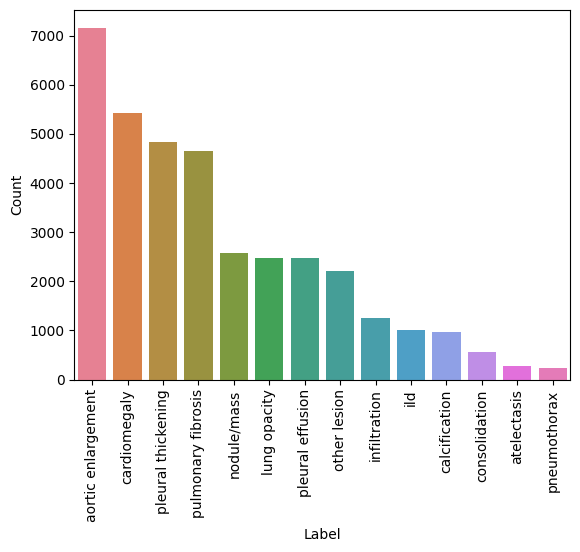

In [32]:
counts = annotations['class_name'].value_counts().tolist()
labels = ["aortic enlargement", "cardiomegaly", "pleural thickening", "pulmonary fibrosis", "nodule/mass", "lung opacity", "pleural effusion", "other lesion", "infiltration", "ild", "calcification", "consolidation", "atelectasis", "pneumothorax"]

import seaborn as sns
import matplotlib.pyplot as plt

dict = {"lbl": labels, "cnt": counts}

df = pd.DataFrame(dict)
df.columns = ["Label", "Count"]

plot = sns.barplot(df, x="Label", y="Count", hue="Label")
plt.setp(plot.get_xticklabels(), rotation=90)